Upload ENB2012_data.csv


Saving ENB2012_data.csv to ENB2012_data.csv

Dataset Loaded Successfully



,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28



Dataset Information



,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


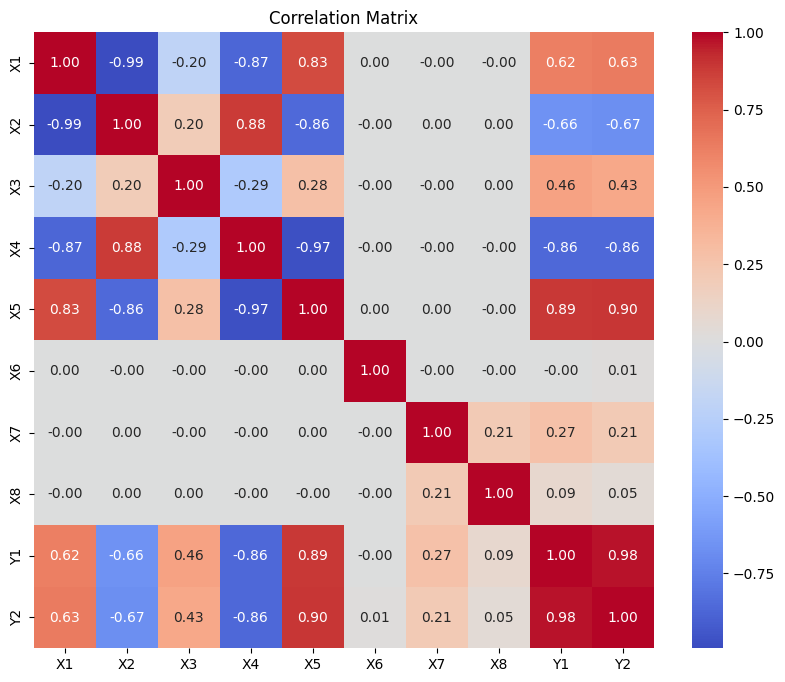


Correlation between Heating Load (Y1) and Cooling Load (Y2): 0.9759


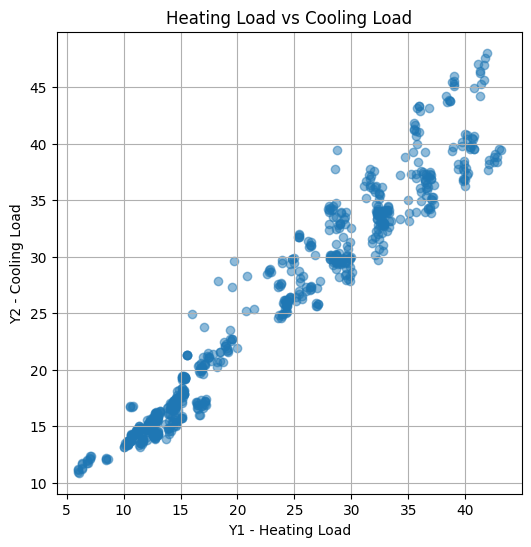


SEPARATE GP MODELS
Heating Load (Y1): R² = 0.9978, RMSE = 0.4825
Cooling Load (Y2): R² = 0.9958, RMSE = 0.6257

Explained Variance Ratio
[0.98819994 0.01180006]

PCA Components
[[ 0.72819507  0.68536993]
 [-0.68536993  0.72819507]]

PC1 R² = 0.9970

SINGLE PARAMETER GP (PC1)
Heating Load (Y1): R² = 0.9882, RMSE = 1.1076
Cooling Load (Y2): R² = 0.9794, RMSE = 1.3831


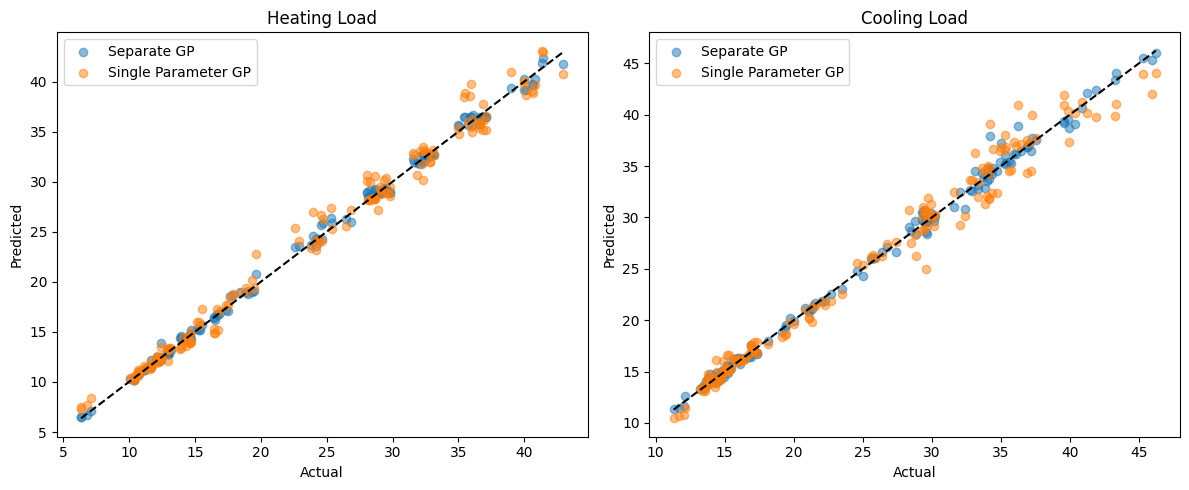


SUMMARY RESULTS


,Model,R2,RMSE
0,Separate GP - Y1,0.997766,0.482514
1,Separate GP - Y2,0.995775,0.625666
2,Single GP (PC1) - Y1,0.988230,1.107628
3,Single GP (PC1) - Y2,0.979355,1.383077


In [2]:
# ============================================================
# Energy Efficiency Dataset (ENB2012)
# Gaussian Process Regression + PCA
# Fully Colab-Compatible Version
# ============================================================

# Install required packages (safe to run in Colab)
!pip -q install scikit-learn seaborn

# ============================================================
# Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel
)
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. Upload and Load Dataset
# ============================================================

print("Upload ENB2012_data.csv")

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("\nDataset Loaded Successfully\n")
display(df.head())

# ============================================================
# 2. Exploratory Data Analysis
# ============================================================

print("\nDataset Information\n")
display(df.describe())

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

corr_y1_y2 = df['Y1'].corr(df['Y2'])

print(
    f"\nCorrelation between Heating Load (Y1) and Cooling Load (Y2): "
    f"{corr_y1_y2:.4f}"
)

plt.figure(figsize=(6,6))
plt.scatter(df['Y1'], df['Y2'], alpha=0.5)
plt.xlabel("Y1 - Heating Load")
plt.ylabel("Y2 - Cooling Load")
plt.title("Heating Load vs Cooling Load")
plt.grid(True)
plt.show()

# ============================================================
# 3. Prepare Features and Targets
# ============================================================

feature_cols = ['X1','X2','X3','X4','X5','X6','X7','X8']

X = df[feature_cols].values
Y = df[['Y1','Y2']].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# 4. Standardization
# ============================================================

scaler_X = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# ============================================================
# 5. Define Stable Kernel
# ============================================================

kernel = (
    ConstantKernel(
        1.0,
        (1e-3, 1e3)
    )
    *
    RBF(
        length_scale=np.ones(X_train_s.shape[1]),
        length_scale_bounds=(1e-2, 1e2)
    )
    +
    WhiteKernel(
        noise_level=1.0,
        noise_level_bounds=(1e-5, 1e1)
    )
)

# ============================================================
# 6. Separate GP Models
# ============================================================

gpr_y1 = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=1,
    random_state=42
)

gpr_y2 = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=1,
    random_state=42
)

gpr_y1.fit(X_train_s, Y_train[:,0])
gpr_y2.fit(X_train_s, Y_train[:,1])

y1_pred = gpr_y1.predict(X_test_s)
y2_pred = gpr_y2.predict(X_test_s)

r2_y1 = r2_score(Y_test[:,0], y1_pred)
rmse_y1 = np.sqrt(mean_squared_error(Y_test[:,0], y1_pred))

r2_y2 = r2_score(Y_test[:,1], y2_pred)
rmse_y2 = np.sqrt(mean_squared_error(Y_test[:,1], y2_pred))

print("\n==============================")
print("SEPARATE GP MODELS")
print("==============================")

print(
    f"Heating Load (Y1): "
    f"R² = {r2_y1:.4f}, "
    f"RMSE = {rmse_y1:.4f}"
)

print(
    f"Cooling Load (Y2): "
    f"R² = {r2_y2:.4f}, "
    f"RMSE = {rmse_y2:.4f}"
)

# ============================================================
# 7. PCA Transformation
# ============================================================

pca = PCA(n_components=2)

Y_train_pca = pca.fit_transform(Y_train)
Y_test_pca = pca.transform(Y_test)

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

print("\nPCA Components")
print(pca.components_)

# ============================================================
# 8. Single-Parameter GP using PC1
# ============================================================

gpr_pc1 = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=1,
    random_state=42
)

gpr_pc1.fit(
    X_train_s,
    Y_train_pca[:,0]
)

pc1_pred = gpr_pc1.predict(X_test_s)

pc1_r2 = r2_score(
    Y_test_pca[:,0],
    pc1_pred
)

print(f"\nPC1 R² = {pc1_r2:.4f}")

# ============================================================
# 9. Reconstruct Y1 and Y2 from PC1
# ============================================================

Y_test_pca_recon = np.zeros(
    (len(pc1_pred), 2)
)

Y_test_pca_recon[:,0] = pc1_pred

Y_pred_from_pc1 = pca.inverse_transform(
    Y_test_pca_recon
)

r2_pc1_y1 = r2_score(
    Y_test[:,0],
    Y_pred_from_pc1[:,0]
)

rmse_pc1_y1 = np.sqrt(
    mean_squared_error(
        Y_test[:,0],
        Y_pred_from_pc1[:,0]
    )
)

r2_pc1_y2 = r2_score(
    Y_test[:,1],
    Y_pred_from_pc1[:,1]
)

rmse_pc1_y2 = np.sqrt(
    mean_squared_error(
        Y_test[:,1],
        Y_pred_from_pc1[:,1]
    )
)

print("\n==============================")
print("SINGLE PARAMETER GP (PC1)")
print("==============================")

print(
    f"Heating Load (Y1): "
    f"R² = {r2_pc1_y1:.4f}, "
    f"RMSE = {rmse_pc1_y1:.4f}"
)

print(
    f"Cooling Load (Y2): "
    f"R² = {r2_pc1_y2:.4f}, "
    f"RMSE = {rmse_pc1_y2:.4f}"
)

# ============================================================
# 10. Comparison Plots
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# Heating Load

axes[0].scatter(
    Y_test[:,0],
    y1_pred,
    alpha=0.5,
    label='Separate GP'
)

axes[0].scatter(
    Y_test[:,0],
    Y_pred_from_pc1[:,0],
    alpha=0.5,
    label='Single Parameter GP'
)

axes[0].plot(
    [Y_test[:,0].min(), Y_test[:,0].max()],
    [Y_test[:,0].min(), Y_test[:,0].max()],
    'k--'
)

axes[0].set_title("Heating Load")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].legend()

# Cooling Load

axes[1].scatter(
    Y_test[:,1],
    y2_pred,
    alpha=0.5,
    label='Separate GP'
)

axes[1].scatter(
    Y_test[:,1],
    Y_pred_from_pc1[:,1],
    alpha=0.5,
    label='Single Parameter GP'
)

axes[1].plot(
    [Y_test[:,1].min(), Y_test[:,1].max()],
    [Y_test[:,1].min(), Y_test[:,1].max()],
    'k--'
)

axes[1].set_title("Cooling Load")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 11. Results Summary Table
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Separate GP - Y1',
        'Separate GP - Y2',
        'Single GP (PC1) - Y1',
        'Single GP (PC1) - Y2'
    ],
    'R2': [
        r2_y1,
        r2_y2,
        r2_pc1_y1,
        r2_pc1_y2
    ],
    'RMSE': [
        rmse_y1,
        rmse_y2,
        rmse_pc1_y1,
        rmse_pc1_y2
    ]
})

print("\n==============================")
print("SUMMARY RESULTS")
print("==============================")

display(results)

Upload green_building_dataset.csv


Saving green_building_dataset.csv to green_building_dataset.csv

Dataset Loaded Successfully
Shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932



Numeric columns found:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

Correlation with Target


,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
activity_level,0.018522
wind_speed,0.011333
indoor_humidity,0.007899


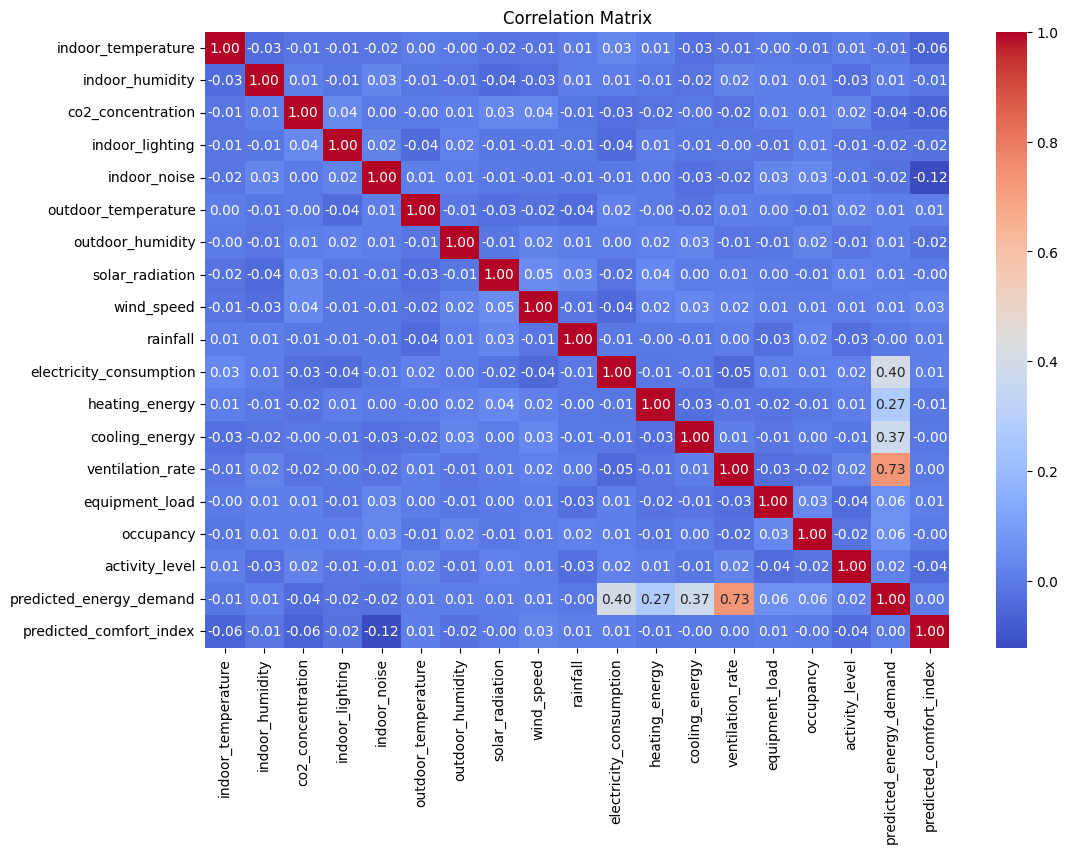


Variance Inflation Factors


,Feature,VIF
0,const,19.689851
1,ventilation_rate,1.003750
2,electricity_consumption,1.002370
3,cooling_energy,1.000894
4,heating_energy,1.001471
5,equipment_load,1.002673
6,occupancy,1.001741



LINEAR REGRESSION RESULTS
R² Score : 0.9613
RMSE     : 1.9014


,Feature,Coefficient
0,ventilation_rate,0.050015
1,electricity_consumption,0.293144
2,cooling_energy,0.250241
3,heating_energy,0.249021
4,equipment_load,0.095229
5,occupancy,0.045714


Intercept = 0.29222567504664454

OLS Regression Summary
                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.952
Model:                                 OLS   Adj. R-squared:                  0.952
Method:                      Least Squares   F-statistic:                     6368.
Date:                     Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                             17:36:15   Log-Likelihood:                -4131.8
No. Observations:                     1920   AIC:                             8278.
Df Residuals:                         1913   BIC:                             8316.
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------

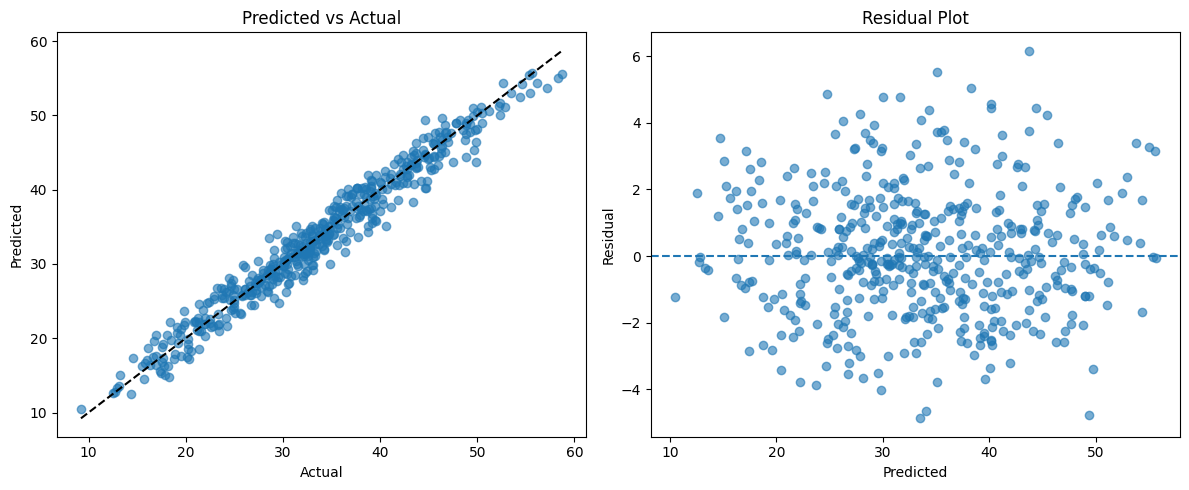


Feature Importance


,Feature,Standardized Coefficient
0,ventilation_rate,7.186985
1,electricity_consumption,4.173845
2,cooling_energy,3.572883
3,heating_energy,2.866355
4,equipment_load,0.824891
5,occupancy,0.665213



Model Summary


,Metric,Value
0,R²,0.961275
1,RMSE,1.901386


In [4]:
# ============================================================
# Install dependencies
# ============================================================

!pip -q install statsmodels seaborn

# ============================================================
# Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# Upload Dataset
# ============================================================

print("Upload green_building_dataset.csv")

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("\nDataset Loaded Successfully")
print("Shape:", df.shape)

display(df.head())

# ============================================================
# Dataset Summary
# ============================================================

display(df.describe())

# ============================================================
# Keep only numeric columns
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

print("\nNumeric columns found:")
print(list(numeric_df.columns))

# ============================================================
# Verify target column exists
# ============================================================

target = 'predicted_energy_demand'

if target not in numeric_df.columns:
    raise ValueError(
        f"Target column '{target}' not found.\n"
        f"Available columns:\n{list(numeric_df.columns)}"
    )

# ============================================================
# Correlation Analysis
# ============================================================

corr_matrix = numeric_df.corr()

corr_with_target = (
    corr_matrix[target]
    .sort_values(ascending=False)
)

print("\nCorrelation with Target")
display(corr_with_target)

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# Feature Selection
# ============================================================

features = [
    'ventilation_rate',
    'electricity_consumption',
    'cooling_energy',
    'heating_energy',
    'equipment_load',
    'occupancy'
]

# Verify features exist
missing_features = [f for f in features if f not in df.columns]

if len(missing_features) > 0:
    raise ValueError(
        f"Missing columns:\n{missing_features}"
    )

X = df[features]
y = df[target]

# Remove missing values if any
data = pd.concat([X, y], axis=1).dropna()

X = data[features]
y = data[target]

# ============================================================
# VIF Calculation
# ============================================================

X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_const.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_const.values,
        i
    )
    for i in range(X_const.shape[1])
]

print("\nVariance Inflation Factors")
display(vif)

# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# Linear Regression Model
# ============================================================

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n==========================")
print("LINEAR REGRESSION RESULTS")
print("==========================")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
})

display(coef_df)

print("Intercept =", lr.intercept_)

# ============================================================
# OLS Statistical Model
# ============================================================

X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

print("\nOLS Regression Summary")
print(ols_model.summary())

# ============================================================
# Diagnostic Plots
# ============================================================

residuals = y_test - y_pred

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# Predicted vs Actual

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

axes[0].set_title("Predicted vs Actual")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Residual Plot

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6
)

axes[1].axhline(
    0,
    linestyle='--'
)

axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

# ============================================================
# Standardized Coefficients
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

lr_scaled = LinearRegression()

lr_scaled.fit(
    X_train_scaled,
    y_train
)

importance = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': lr_scaled.coef_
})

importance = importance.sort_values(
    by='Standardized Coefficient',
    key=abs,
    ascending=False
)

print("\nFeature Importance")
display(importance)

# ============================================================
# Final Summary Table
# ============================================================

summary = pd.DataFrame({
    "Metric": ["R²", "RMSE"],
    "Value": [r2, rmse]
})

print("\nModel Summary")
display(summary)